[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JaimeHuaytallaPariona/ingenieria-conocimiento-uncp/blob/master/recursos/sesion_02_modelos_clasificacion.ipynb)

# Sesión 02 — Modelos de Clasificación
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Implementar, comparar y analizar cuatro modelos fundamentales de clasificación supervisada — **Regresión Logística, Árbol de Decisión, SVM y KNN** — sobre el dataset **Wine Quality** de UCI, evaluando sus fortalezas, limitaciones y sensibilidad al preprocesamiento.

## 1. Configuración del entorno

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    accuracy_score, f1_score
)
from sklearn.inspection import DecisionBoundaryDisplay

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Carga y comprensión del dataset

Utilizamos el **Wine Quality (Red)** del repositorio UCI Machine Learning. Contiene 1599 muestras de vino tinto portugués con 11 atributos fisicoquímicos y una puntuación de calidad (3–8).

Para construir un problema de **clasificación binaria**, definimos:
- **Clase 1 (Bueno):** calidad ≥ 7
- **Clase 0 (Estándar):** calidad < 7

Esta binarización genera un **problema desbalanceado**, lo que añade un reto realista al modelado.

In [3]:
# Carga directa desde UCI
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

df = pd.read_csv(URL, sep=';')
print(f'Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')
df.head()

Dataset cargado: 1599 registros, 12 columnas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Distribución de calidad original:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


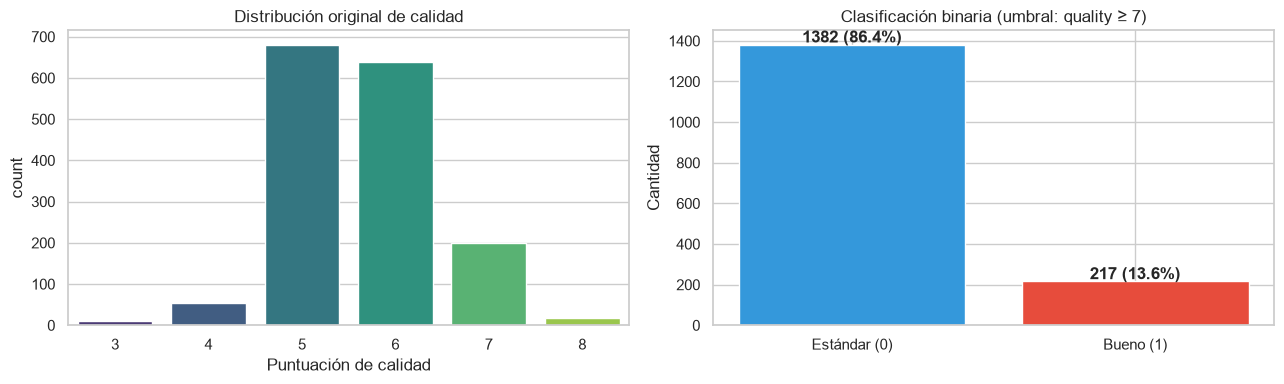


Ratio de desbalance: 6.4:1 (Estándar vs Bueno)


In [4]:
# Distribución original de la variable 'quality'
print('Distribución de calidad original:')
print(df['quality'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma original
sns.countplot(data=df, x='quality', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución original de calidad')
axes[0].set_xlabel('Puntuación de calidad')

# Binarización
df['quality_label'] = (df['quality'] >= 7).astype(int)

counts = df['quality_label'].value_counts()
axes[1].bar(['Estándar (0)', 'Bueno (1)'], counts.values,
            color=['#3498db', '#e74c3c'])
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 10, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Clasificación binaria (umbral: quality ≥ 7)')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

print(f'\nRatio de desbalance: {counts[0]/counts[1]:.1f}:1 (Estándar vs Bueno)')

---
## 3. Análisis exploratorio orientado a clasificación

In [5]:
# 3.1  Estadísticas descriptivas por clase
features = df.columns.drop(['quality', 'quality_label'])

comparison = df.groupby('quality_label')[features].mean().T
comparison.columns = ['Estándar (0)', 'Bueno (1)']
comparison['Diferencia %'] = ((comparison['Bueno (1)'] - comparison['Estándar (0)']) / comparison['Estándar (0)'] * 100).round(1)
comparison.style.background_gradient(subset=['Diferencia %'], cmap='RdYlGn')

,Estándar (0),Bueno (1),Diferencia %
fixed acidity,8.236831,8.847005,7.400000
volatile acidity,0.547022,0.405530,-25.900000
citric acid,0.254407,0.376498,48.000000
residual sugar,2.512120,2.708756,7.800000
chlorides,0.089281,0.075912,-15.000000
free sulfur dioxide,16.172214,13.981567,-13.500000
total sulfur dioxide,48.285818,34.889401,-27.700000
density,0.996859,0.996030,-0.100000
pH,3.314616,3.288802,-0.800000
sulphates,0.644754,0.743456,15.300000


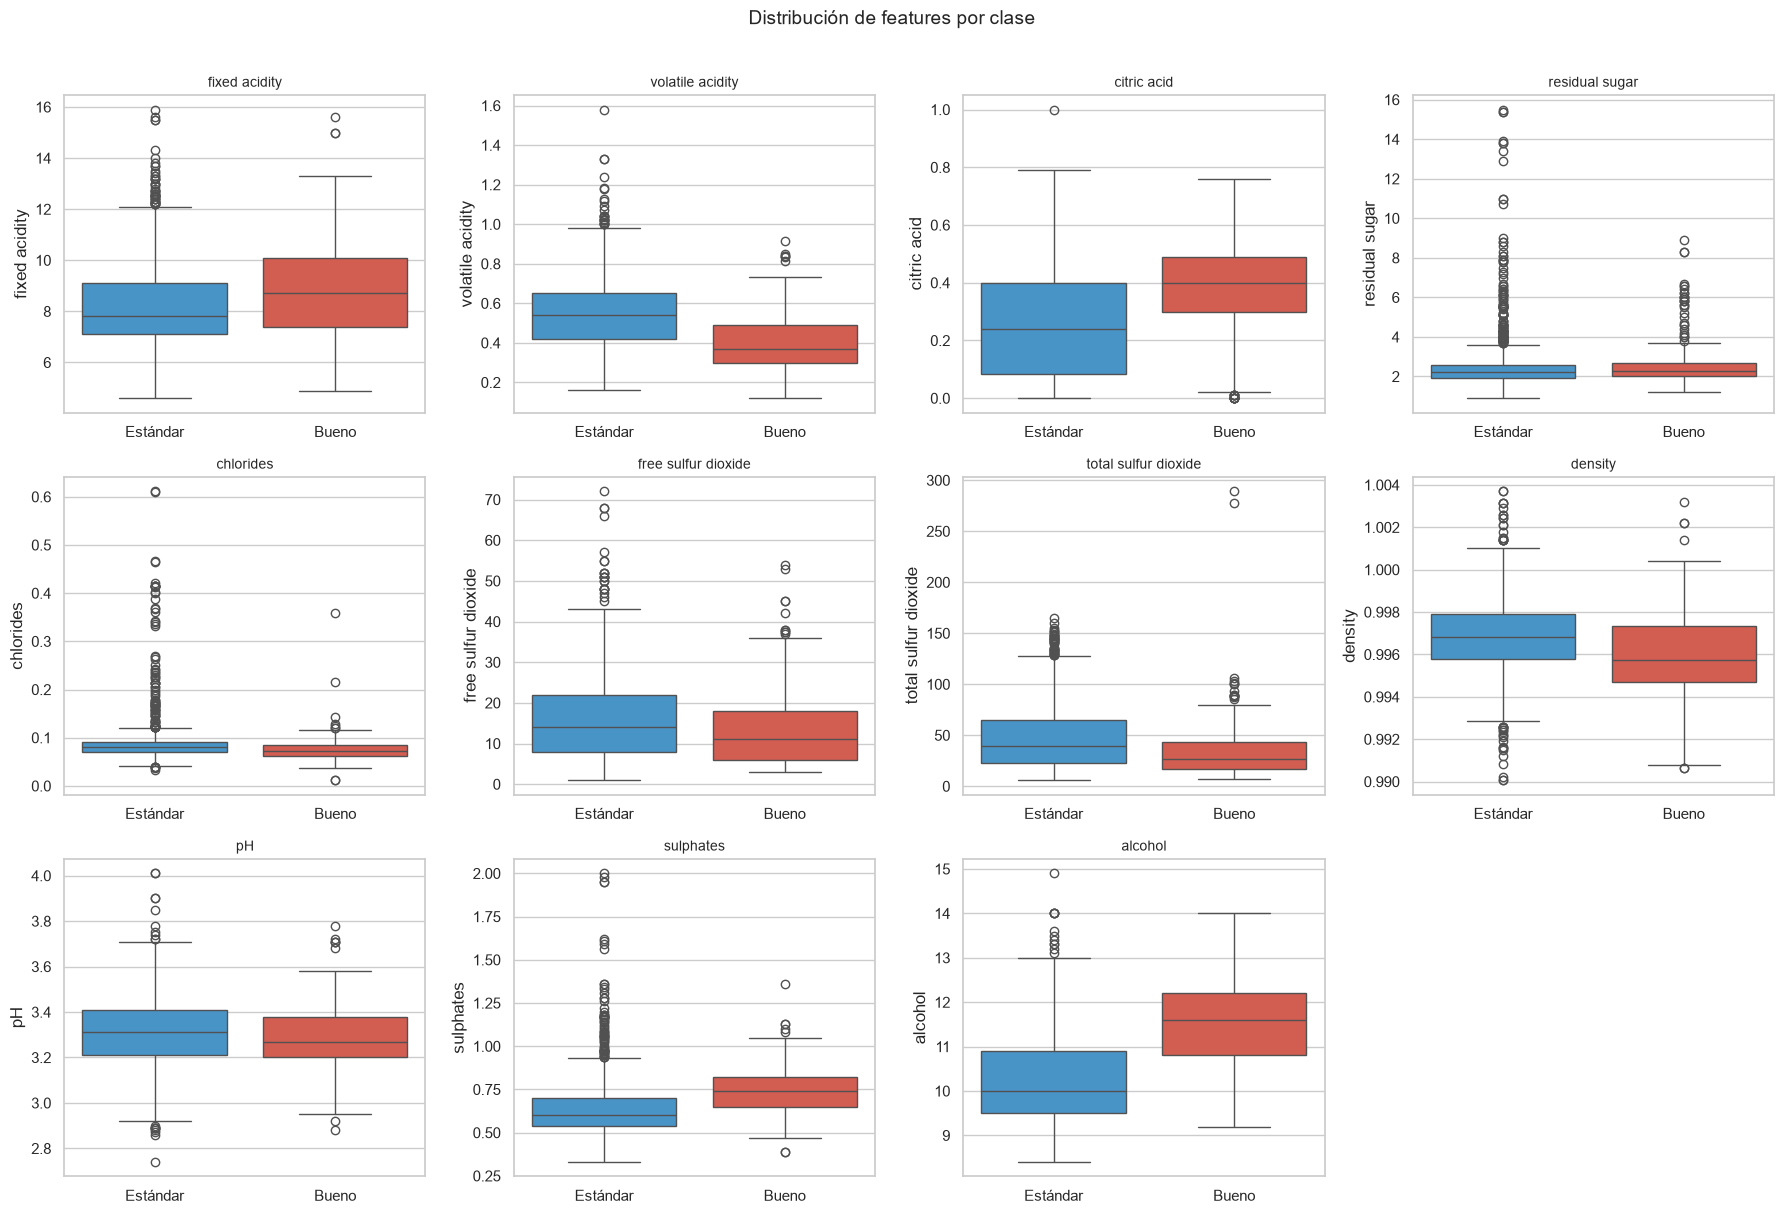

In [6]:
# 3.2  Distribución de features por clase (boxplots)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='quality_label', y=col, ax=axes[i],
                palette=['#3498db', '#e74c3c'], hue='quality_label', legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Estándar', 'Bueno'])

# Ocultar subplot vacío
axes[-1].set_visible(False)
fig.suptitle('Distribución de features por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

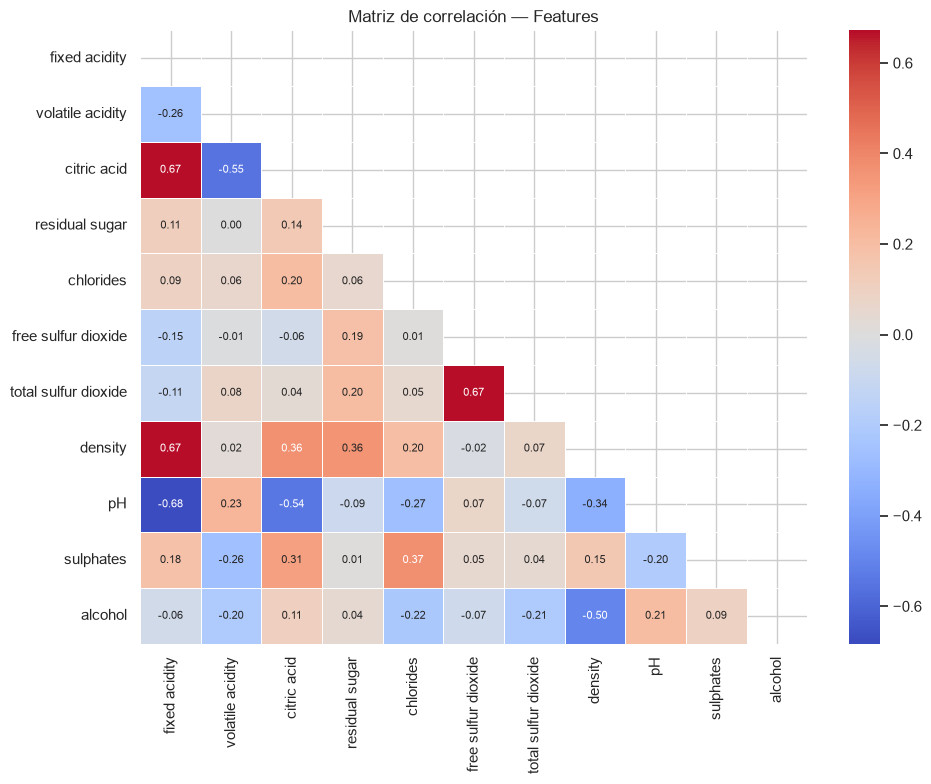

In [7]:
# 3.3  Correlación entre features
plt.figure(figsize=(10, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de correlación — Features')
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [8]:
# 4.1  Separación features / target
X = df[features].copy()
y = df['quality_label'].copy()

# 4.2  Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras')
print(f'Proporción clase 1 en train: {y_train.mean():.3f}')
print(f'Proporción clase 1 en test:  {y_test.mean():.3f}')

Train: 1279 muestras  |  Test: 320 muestras
Proporción clase 1 en train: 0.136
Proporción clase 1 en test:  0.134


In [9]:
# 4.3  Verificación de escalas (justifica la estandarización)
print('Rangos de las features (train):')
print('='*50)
for col in features:
    mn, mx = X_train[col].min(), X_train[col].max()
    print(f'{col:30s}  [{mn:8.2f}, {mx:8.2f}]  rango: {mx-mn:.2f}')

print('\n→ Las escalas difieren significativamente entre features.')
print('  Esto afecta directamente a SVM y KNN (basados en distancias).')
print('  Logistic Regression también se beneficia de la estandarización.')

Rangos de las features (train):
fixed acidity                   [    4.60,    15.90]  rango: 11.30
volatile acidity                [    0.12,     1.58]  rango: 1.46
citric acid                     [    0.00,     1.00]  rango: 1.00
residual sugar                  [    0.90,    15.50]  rango: 14.60
chlorides                       [    0.01,     0.61]  rango: 0.60
free sulfur dioxide             [    1.00,    72.00]  rango: 71.00
total sulfur dioxide            [    6.00,   165.00]  rango: 159.00
density                         [    0.99,     1.00]  rango: 0.01
pH                              [    2.74,     4.01]  rango: 1.27
sulphates                       [    0.33,     2.00]  rango: 1.67
alcohol                         [    8.40,    14.90]  rango: 6.50

→ Las escalas difieren significativamente entre features.
  Esto afecta directamente a SVM y KNN (basados en distancias).
  Logistic Regression también se beneficia de la estandarización.


---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima la probabilidad de pertenencia a una clase mediante la función sigmoide. Ideal como **baseline** por su interpretabilidad y eficiencia.

In [10]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                               class_weight='balanced'))  # Compensar desbalance
])

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='f1')
print(f'Logistic Regression — F1 CV: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')

# Entrenamiento final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Logistic Regression — F1 CV: 0.5045 ± 0.0355


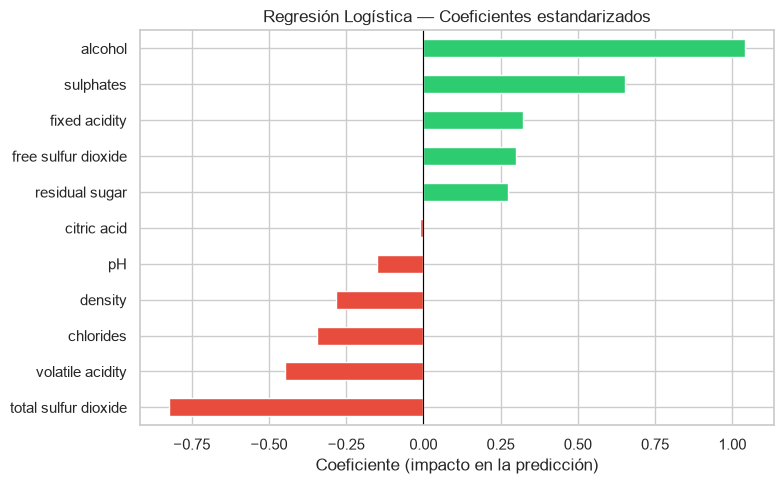


Interpretación: Un coeficiente positivo alto indica que valores mayores
de esa feature incrementan la probabilidad de clasificar como "Bueno".


In [11]:
# 5.2  Coeficientes del modelo (interpretabilidad)
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=features
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs.values]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Regresión Logística — Coeficientes estandarizados')
ax.set_xlabel('Coeficiente (impacto en la predicción)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nInterpretación: Un coeficiente positivo alto indica que valores mayores')
print('de esa feature incrementan la probabilidad de clasificar como "Bueno".')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** Modelo no lineal que particiona el espacio de features mediante reglas if-else jerárquicas. Altamente interpretable, pero propenso al sobreajuste si no se controla la profundidad.

In [12]:
# 6.1  Pipeline (no requiere estandarización)
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

scores_dt = cross_val_score(pipe_dt, X_train, y_train, cv=cv, scoring='f1')
print(f'Decision Tree — F1 CV: {scores_dt.mean():.4f} ± {scores_dt.std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Decision Tree — F1 CV: 0.5126 ± 0.0331


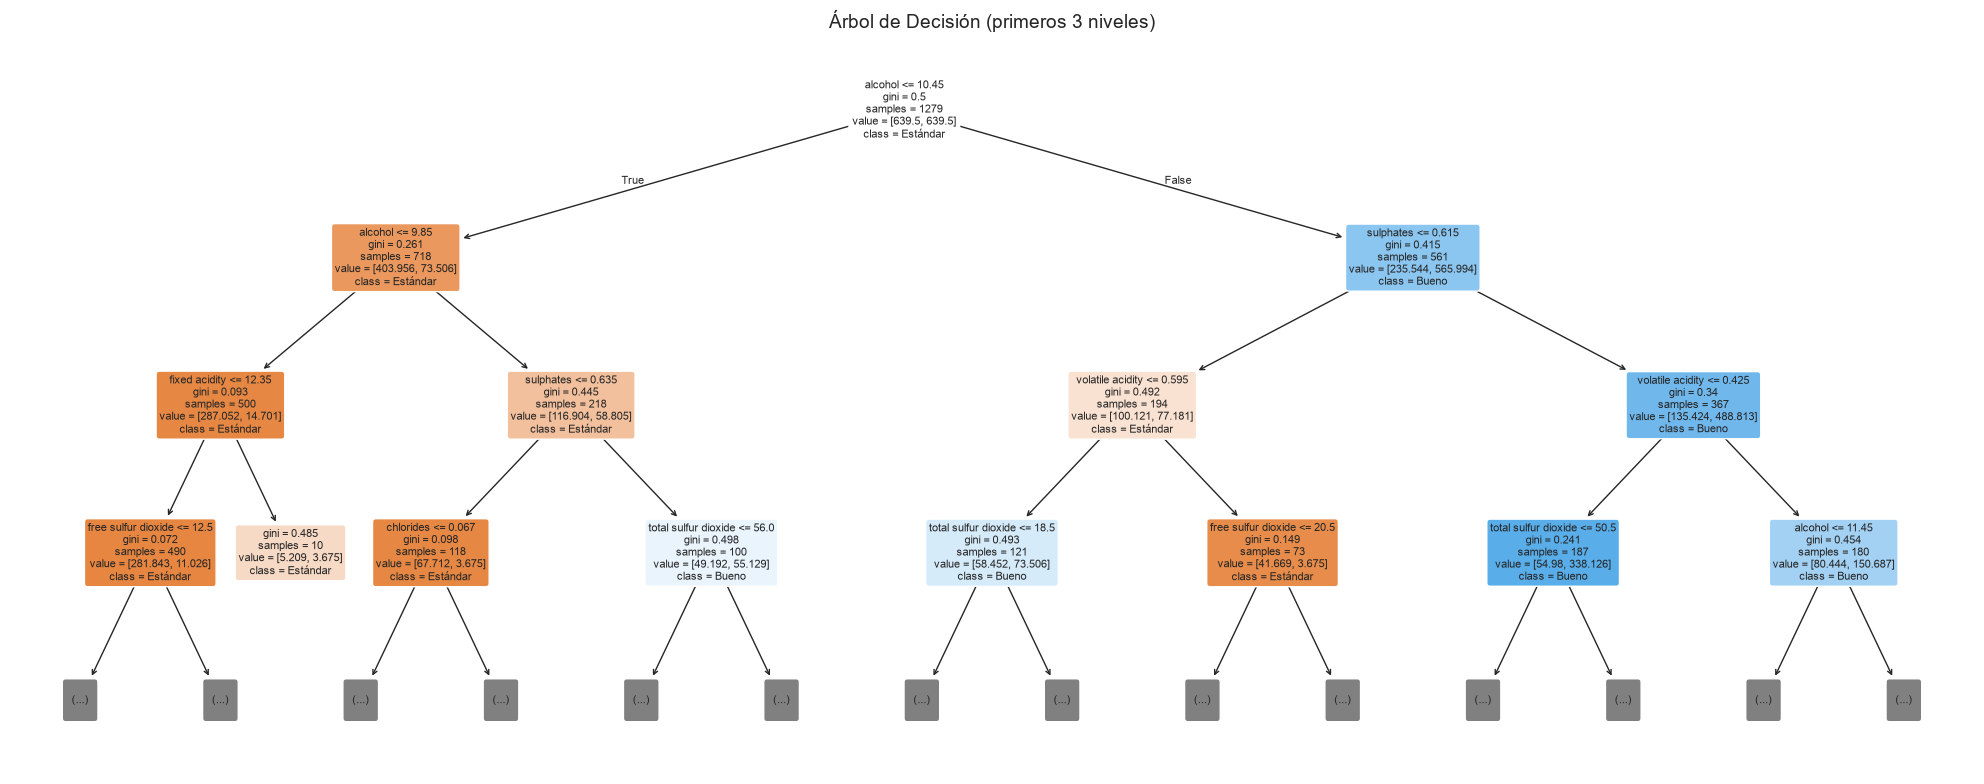

In [13]:
# 6.2  Visualización del árbol
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    pipe_dt.named_steps['clf'],
    feature_names=list(features),
    class_names=['Estándar', 'Bueno'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    max_depth=3  # Mostrar solo 3 niveles para legibilidad
)
ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

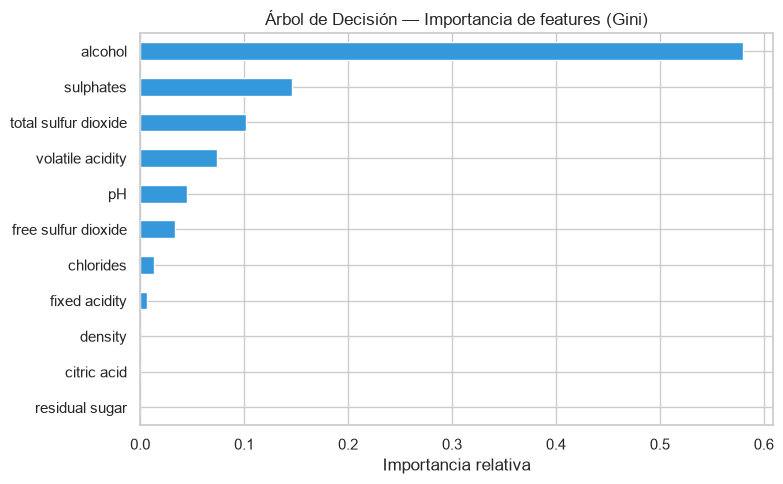

In [14]:
# 6.3  Importancia de features (Gini importance)
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Árbol de Decisión — Importancia de features (Gini)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

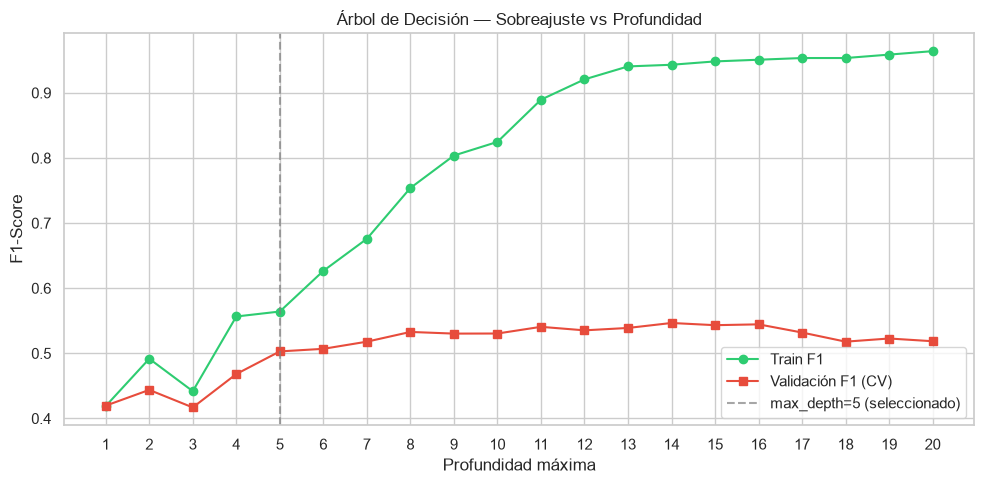

Observación: cuando la brecha entre train y validación crece,
el modelo está sobreajustando (memorizando el train set).


In [15]:
# 6.4  Efecto de la profundidad en sobreajuste/subajuste
depths = range(1, 21)
train_scores = []
val_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                 random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    train_scores.append(f1_score(y_train, dt.predict(X_train)))
    cv_s = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1')
    val_scores.append(cv_s.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_scores, 'o-', label='Train F1', color='#2ecc71')
ax.plot(depths, val_scores, 's-', label='Validación F1 (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1-Score')
ax.set_title('Árbol de Decisión — Sobreajuste vs Profundidad')
ax.legend()
ax.set_xticks(depths)
plt.tight_layout()
plt.show()

print('Observación: cuando la brecha entre train y validación crece,')
print('el modelo está sobreajustando (memorizando el train set).')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** Busca el hiperplano que maximiza el margen de separación entre clases. Con funciones kernel puede manejar fronteras no lineales. Es **sensible a la escala** de las features.

In [16]:
# 7.1  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    pipe_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=kernel, class_weight='balanced',
                     random_state=RANDOM_STATE, probability=True))
    ])
    scores = cross_val_score(pipe_svm, X_train, y_train, cv=cv, scoring='f1')
    svm_results[kernel] = scores
    print(f'SVM ({kernel:6s}) — F1 CV: {scores.mean():.4f} ± {scores.std():.4f}')

# Seleccionar el mejor kernel
best_kernel = max(svm_results, key=lambda k: svm_results[k].mean())
print(f'\nMejor kernel: {best_kernel}')

SVM (linear) — F1 CV: 0.4982 ± 0.0237
SVM (rbf   ) — F1 CV: 0.5246 ± 0.0427
SVM (poly  ) — F1 CV: 0.5355 ± 0.0258

Mejor kernel: poly


In [17]:
# 7.2  Entrenamiento con el mejor kernel
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel=best_kernel, class_weight='balanced',
                 random_state=RANDOM_STATE, probability=True))
])

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
scores_svm = svm_results[best_kernel]

In [18]:
# 7.3  Impacto de la estandarización en SVM
# SVM SIN estandarizar
svm_no_scale = SVC(kernel=best_kernel, class_weight='balanced',
                    random_state=RANDOM_STATE)
scores_no_scale = cross_val_score(svm_no_scale, X_train, y_train, cv=cv, scoring='f1')

print('Impacto de la estandarización en SVM:')
print(f'  CON StandardScaler: F1 = {scores_svm.mean():.4f}')
print(f'  SIN StandardScaler: F1 = {scores_no_scale.mean():.4f}')
print(f'  Diferencia: {(scores_svm.mean() - scores_no_scale.mean())*100:+.2f} puntos porcentuales')
print('\n→ La estandarización es CRÍTICA para modelos basados en distancias.')

Impacto de la estandarización en SVM:
  CON StandardScaler: F1 = 0.5355
  SIN StandardScaler: F1 = 0.2832
  Diferencia: +25.23 puntos porcentuales

→ La estandarización es CRÍTICA para modelos basados en distancias.


---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Clasifica según la mayoría de votos de los K vecinos más cercanos. No paramétrico, sensible a la escala y a la dimensionalidad. El valor de K controla el trade-off bias-varianza.

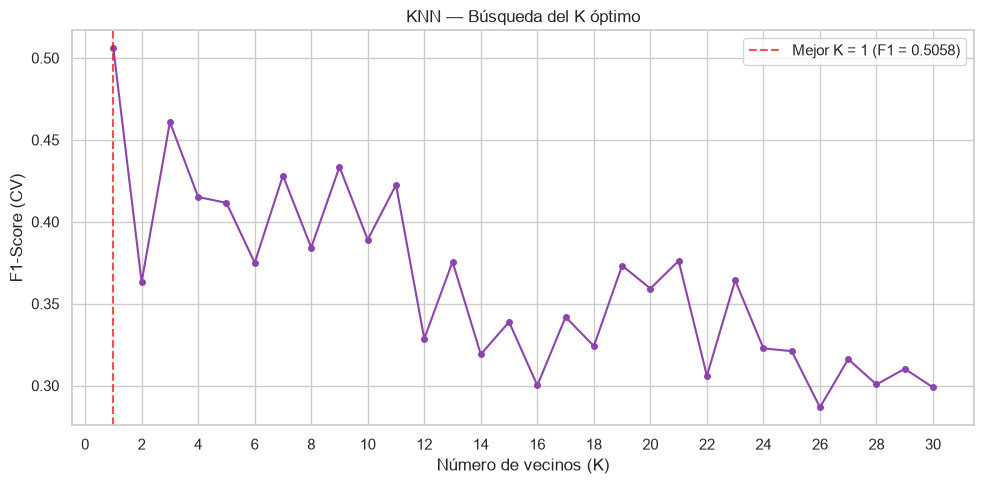

K óptimo: 1


In [19]:
# 8.1  Búsqueda del K óptimo
k_range = range(1, 31)
k_scores = []

for k in k_range:
    pipe_knn = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores, 'o-', markersize=4, color='#8e44ad')
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
           label=f'Mejor K = {best_k} (F1 = {max(k_scores):.4f})')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1-Score (CV)')
ax.set_title('KNN — Búsqueda del K óptimo')
ax.legend()
ax.set_xticks(range(0, 31, 2))
plt.tight_layout()
plt.show()

print(f'K óptimo: {best_k}')

In [20]:
# 8.2  Entrenamiento con K óptimo
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k))
])

scores_knn = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
print(f'KNN (K={best_k}) — F1 CV: {scores_knn.mean():.4f} ± {scores_knn.std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=1) — F1 CV: 0.5058 ± 0.0254


---
## 9. Análisis comparativo de modelos

In [21]:
# 9.1  Tabla resumen
models = {
    'Logistic Regression': (pipe_lr, y_pred_lr, scores_lr),
    'Decision Tree':       (pipe_dt, y_pred_dt, scores_dt),
    f'SVM ({best_kernel})': (pipe_svm, y_pred_svm, scores_svm),
    f'KNN (K={best_k})':   (pipe_knn, y_pred_knn, scores_knn)
}

summary = []
for name, (pipe, y_pred, cv_scores) in models.items():
    summary.append({
        'Modelo': name,
        'F1 CV (mean)': f'{cv_scores.mean():.4f}',
        'F1 CV (std)': f'{cv_scores.std():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test, y_pred):.4f}',
        'F1 Test': f'{f1_score(y_test, y_pred):.4f}'
    })

summary_df = pd.DataFrame(summary)
print('='*80)
print('COMPARACIÓN DE MODELOS')
print('='*80)
summary_df

COMPARACIÓN DE MODELOS


,Modelo,F1 CV (mean),F1 CV (std),Accuracy Test,F1 Test
0,Logistic Regression,0.5045,0.0355,0.8125,0.5312
1,Decision Tree,0.5126,0.0331,0.8094,0.5414
2,SVM (poly),0.5355,0.0258,0.8969,0.6598
3,KNN (K=1),0.5058,0.0254,0.9094,0.6588


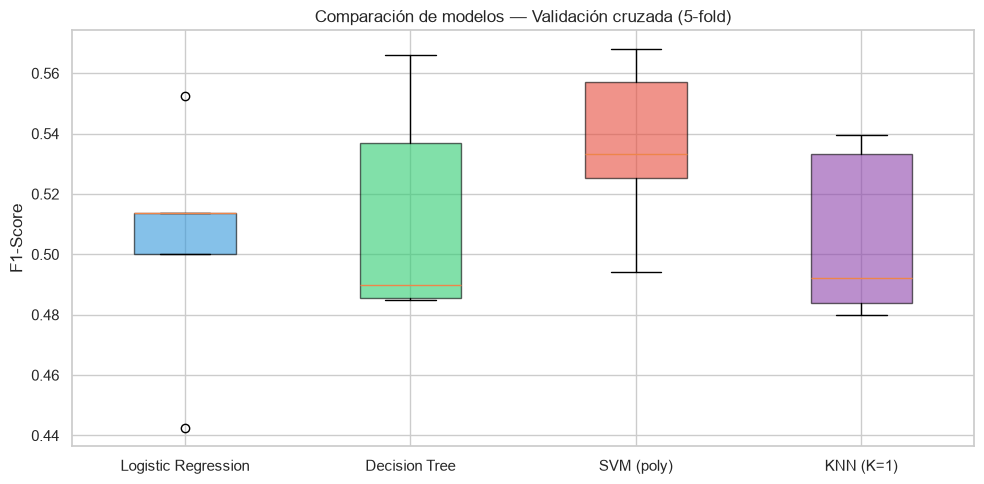

In [22]:
# 9.2  Boxplot comparativo de validación cruzada
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = [scores_lr, scores_dt, scores_svm, scores_knn]
labels = list(models.keys())
bp = ax.boxplot(cv_data, tick_labels=labels, patch_artist=True)
colors_box = ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('F1-Score')
ax.set_title('Comparación de modelos — Validación cruzada (5-fold)')
plt.tight_layout()
plt.show()

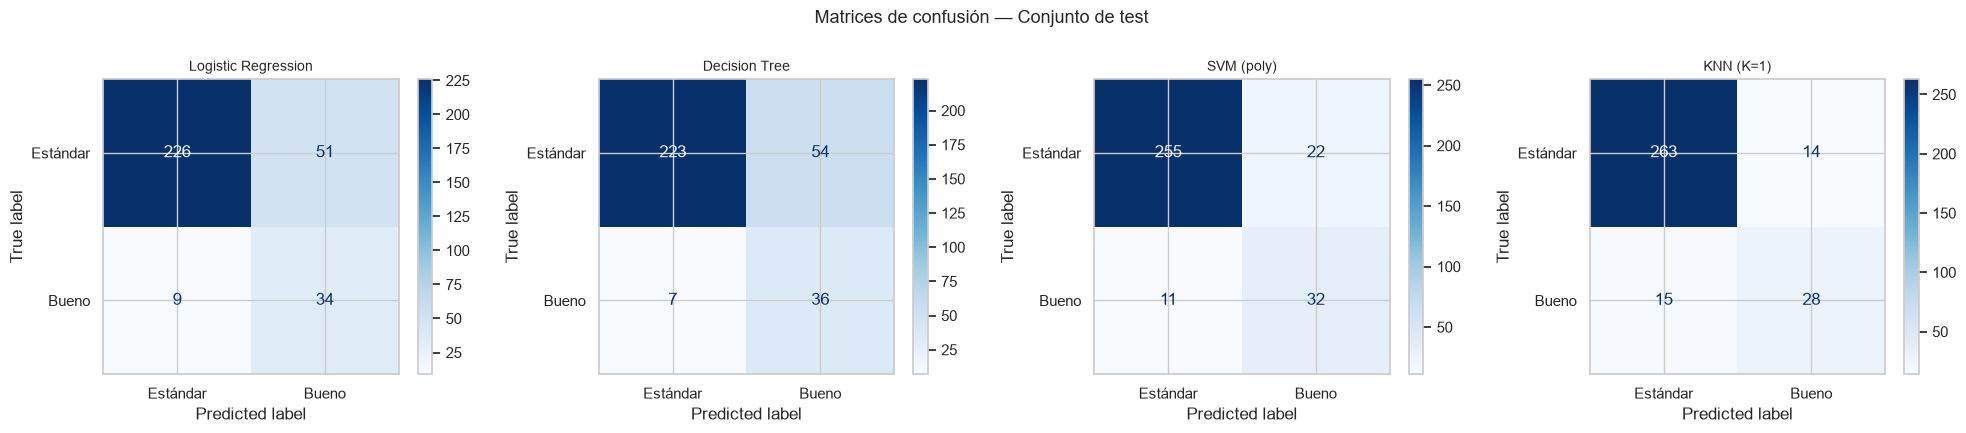

In [23]:
# 9.3  Matrices de confusión comparativas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, (pipe, y_pred, _)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Estándar', 'Bueno'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=10)

fig.suptitle('Matrices de confusión — Conjunto de test', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

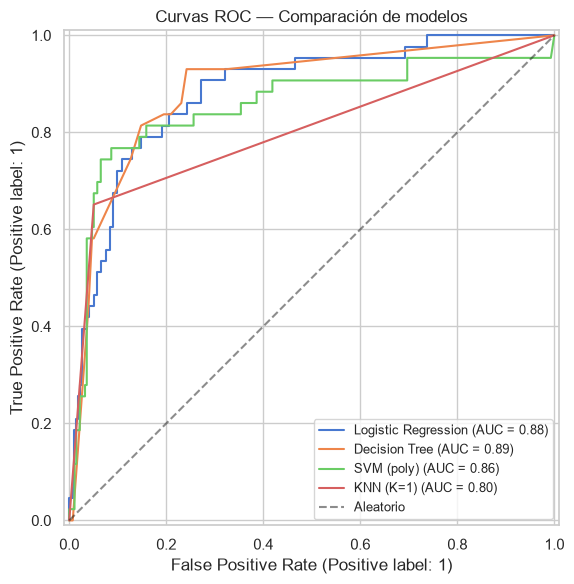

In [24]:
# 9.4  Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 6))

for name, (pipe, _, _) in models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [25]:
# 9.5  Classification report detallado del mejor modelo
best_model_name = max(models, key=lambda k: float(models[k][2].mean()))
best_pipe, best_pred, best_cv = models[best_model_name]

print(f'\nMejor modelo: {best_model_name}')
print('='*60)
print(classification_report(y_test, best_pred,
                             target_names=['Estándar', 'Bueno']))


Mejor modelo: SVM (poly)
              precision    recall  f1-score   support

    Estándar       0.96      0.92      0.94       277
       Bueno       0.59      0.74      0.66        43

    accuracy                           0.90       320
   macro avg       0.78      0.83      0.80       320
weighted avg       0.91      0.90      0.90       320



---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Regresión Logística** | Rápido, interpretable (coeficientes), probabilístico | Asume relación lineal entre features y log-odds | Baseline; cuando la interpretabilidad es prioritaria |
| **Árbol de Decisión** | Interpretable (visualización), maneja no linealidades, no requiere estandarización | Propenso a sobreajuste; inestable (pequeños cambios en datos alteran el árbol) | Cuando se necesitan reglas explicables; como parte de ensambles |
| **SVM** | Efectivo en alta dimensionalidad; flexible con kernels | Sensible a la escala; costoso en datasets grandes; difícil de interpretar | Datasets de tamaño moderado con fronteras complejas |
| **KNN** | Simple, no paramétrico, adaptable | Lento en predicción (distancias contra todo el train); sensible a escala y dimensionalidad | Datasets pequeños-medianos; cuando la frontera es irregular |

---
## 11. Ejercicios propuestos

### Ejercicio 1 — GridSearchCV para SVM
Realice una búsqueda de hiperparámetros para SVM usando `GridSearchCV` con la siguiente grilla:
- `C`: [0.1, 1, 10, 100]
- `gamma`: ['scale', 'auto', 0.01, 0.1]
- `kernel`: ['rbf', 'poly']

Reporte los mejores hiperparámetros, el F1-score obtenido y compare contra el SVM base de la sesión.

### Ejercicio 2 — Clasificación multiclase
En lugar de binarizar la variable `quality`, utilice las clases originales (3–8) y entrene los 4 modelos. Analice:
- ¿Cómo cambia el rendimiento de cada modelo?
- ¿Qué clases son más difíciles de distinguir?
- ¿Qué métrica de F1 es más adecuada: `macro`, `micro` o `weighted`? Justifique.

### Ejercicio 3 — Aplicación con dataset propio
Seleccione un dataset de clasificación de su interés (puede ser de Kaggle, UCI, o datos propios). Debe tener al menos 500 registros y 5 features. Aplique los 4 modelos de clasificación, realice el análisis comparativo completo y documente sus hallazgos.

### Resolución — Ejercicio 1: GridSearchCV para SVM más una línea que diga que se busca sobre 32 combinaciones con CV de 5 folds

In [26]:
from sklearn.model_selection import GridSearchCV

pipe_svm_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(class_weight='balanced', random_state=RANDOM_STATE))
])

param_grid = {
    'clf__C':      [0.1, 1, 10, 100],
    'clf__gamma':  ['scale', 'auto', 0.01, 0.1],
    'clf__kernel': ['rbf', 'poly']
}

grid_svm = GridSearchCV(
    pipe_svm_grid, param_grid,
    cv=cv, scoring='f1',
    n_jobs=-1, return_train_score=True
)

grid_svm.fit(X_train, y_train)

print('Mejores hiperparámetros:', grid_svm.best_params_)
print(f'Mejor F1 (CV): {grid_svm.best_score_:.4f}')

Mejores hiperparámetros: {'clf__C': 10, 'clf__gamma': 0.1, 'clf__kernel': 'rbf'}
Mejor F1 (CV): 0.5450


In [27]:
res = pd.DataFrame(grid_svm.cv_results_)
cols = ['param_clf__kernel', 'param_clf__C', 'param_clf__gamma',
        'mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score']
res[cols].sort_values('rank_test_score').head(10).round(4)

,param_clf__kernel,param_clf__C,param_clf__gamma,mean_train_score,mean_test_score,std_test_score,rank_test_score
22,rbf,10.0,0.1,0.7848,0.5450,0.0413,1
7,poly,0.1,0.1,0.5848,0.5406,0.0445,2
29,poly,100.0,0.01,0.5848,0.5406,0.0445,2
9,poly,1.0,scale,0.6545,0.5355,0.0258,4
11,poly,1.0,auto,0.6545,0.5355,0.0258,4
18,rbf,10.0,auto,0.7688,0.5343,0.0397,6
16,rbf,10.0,scale,0.7688,0.5343,0.0397,6
23,poly,10.0,0.1,0.7378,0.5313,0.0239,8
15,poly,1.0,0.1,0.6641,0.5288,0.0296,9
3,poly,0.1,auto,0.5817,0.5279,0.0448,10


In [28]:
y_pred_grid = grid_svm.predict(X_test)

comparacion = pd.DataFrame({
    'Modelo': [f'SVM base ({best_kernel}, C=1, gamma=scale)', 'SVM optimizado (GridSearchCV)'],
    'F1 CV':  [scores_svm.mean(), grid_svm.best_score_],
    'F1 Test': [f1_score(y_test, y_pred_svm), f1_score(y_test, y_pred_grid)],
    'Accuracy Test': [accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_grid)]
}).round(4)
comparacion

,Modelo,F1 CV,F1 Test,Accuracy Test
0,"SVM base (poly, C=1, gamma=scale)",0.5355,0.6598,0.8969
1,SVM optimizado (GridSearchCV),0.5450,0.6422,0.8781


In [29]:
from sklearn.model_selection import RepeatedStratifiedKFold

rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

svm_base = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel=best_kernel, class_weight='balanced', random_state=RANDOM_STATE))
])
svm_opt = grid_svm.best_estimator_

for nombre, modelo in [('SVM base', svm_base), ('SVM optimizado', svm_opt)]:
    s = cross_val_score(modelo, X_train, y_train, cv=rcv, scoring='f1')
    print(f'{nombre:16s} F1 = {s.mean():.4f} ± {s.std():.4f}  (25 evaluaciones)')

SVM base         F1 = 0.5458 ± 0.0482  (25 evaluaciones)
SVM optimizado   F1 = 0.5433 ± 0.0420  (25 evaluaciones)


### Conclusiones — Ejercicio 1

**Mejores hiperparámetros:** `kernel='rbf'`, `C=10`, `gamma=0.1`, con F1 (CV) = 0.5450.

**Comparación con el SVM base (poly, C=1, gamma=scale):**

| Modelo | F1 CV | F1 Test | Accuracy Test |
|---|---|---|---|
| SVM base | 0.5355 | 0.6598 | 0.8969 |
| SVM optimizado | 0.5450 | 0.6422 | 0.8781 |

**Comparación con validación cruzada repetida (5×5, 25 evaluaciones):**

| Modelo | F1 CV repetida |
|---|---|
| SVM base | 0.5458 ± 0.0482 |
| SVM optimizado | 0.5433 ± 0.0420 |

**Análisis:**
1. La mejora en validación cruzada simple (+0.95 pp) es menor que la desviación estándar entre folds (~0.04). Para verificarlo se repitió la CV 5 veces con particiones distintas (25 evaluaciones): la diferencia fue de −0.25 pp, es decir, ningún modelo supera al otro. En el conjunto de test, el optimizado incluso rinde ligeramente peor (F1 0.6422 vs 0.6598), diferencia que corresponde a pocas muestras dado que el test contiene solo 43 casos positivos.
2. El F1 del mismo modelo base varía ~1 pp según la partición (0.5355 vs 0.5458), magnitud equivalente a la "mejora" aparente del GridSearchCV. Esto confirma que las diferencias observadas pertenecen al ruido de evaluación y que los resultados de una sola partición deben interpretarse con cautela.
3. Las 10 mejores combinaciones se ubican entre 0.528 y 0.545 de F1: existe una meseta de rendimiento y no un óptimo claro. El `best_score_` de GridSearchCV es además una estimación optimista, pues es el máximo de varias combinaciones evaluadas sobre los mismos folds.
4. El modelo ganador presenta una brecha train–CV de ~0.24 (F1 train 0.785), señal de sobreajuste. El modelo poly con C=0.1 (F1 CV 0.541, brecha ~0.04) ofrece un rendimiento equivalente con mayor estabilidad.
5. La grilla contiene redundancias: `gamma='scale'` y `'auto'` coinciden con datos estandarizados de 11 variables, y en el kernel polinomial con coef0=0 solo importa el producto C·γ³.
6. El techo de F1 (~0.54) sugiere que la limitación proviene de los datos (solapamiento entre calidad 6 y 7, pocos positivos) más que de los hiperparámetros. Alternativas: ajustar el umbral de decisión, usar curvas Precision-Recall, ingeniería de variables o modelos de ensamble.

**Conclusión:** la optimización con GridSearchCV no produjo una mejora real sobre el SVM base, ni siquiera con una evaluación más robusta que favorecía al modelo optimizado (sus hiperparámetros se eligieron sobre los mismos datos). El ejercicio muestra que el ajuste fino de hiperparámetros rinde poco cuando el problema está limitado por la calidad y el desbalance de los datos.

### Resolución — Ejercicio 2: Clasificación multiclase (quality 3–8)

In [32]:
# split multiclase y distribución

y_mc = df['quality']

Xmc_train, Xmc_test, ymc_train, ymc_test = train_test_split(
    X, y_mc, test_size=0.20, random_state=RANDOM_STATE, stratify=y_mc
)

dist = pd.DataFrame({
    'Train': ymc_train.value_counts().sort_index(),
    'Test':  ymc_test.value_counts().sort_index()
})
dist['% Train'] = (dist['Train'] / dist['Train'].sum() * 100).round(1)
dist

,Train,Test,% Train
quality,,,
3,8,2,0.6
4,42,11,3.3
5,545,136,42.6
6,510,128,39.9
7,159,40,12.4
8,15,3,1.2


In [ ]:
# validación cruzada de los 4 modelos

from sklearn.model_selection import cross_validate

modelos_mc = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                   random_state=RANDOM_STATE))]),
    'Decision Tree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                       class_weight='balanced',
                                       random_state=RANDOM_STATE))]),
    f'SVM ({best_kernel})': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=best_kernel, class_weight='balanced',
                    random_state=RANDOM_STATE))]),
    'KNN (K=5)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5))])
}

filas = []
for nombre, modelo in modelos_mc.items():
    r = cross_validate(modelo, Xmc_train, ymc_train, cv=cv,
                       scoring=['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted'])
    filas.append({
        'Modelo': nombre,
        'Accuracy CV':    r['test_accuracy'].mean(),
        'F1 micro CV':    r['test_f1_micro'].mean(),
        'F1 macro CV':    r['test_f1_macro'].mean(),
        'F1 weighted CV': r['test_f1_weighted'].mean()
    })

cv_mc = pd.DataFrame(filas).set_index('Modelo').round(4)
cv_mc

,Accuracy CV,F1 micro CV,F1 macro CV,F1 weighted CV
Modelo,,,,
Logistic Regression,0.4402,0.4402,0.2841,0.4841
Decision Tree,0.3323,0.3323,0.2224,0.3513
SVM (poly),0.5574,0.5574,0.3369,0.5659
KNN (K=5),0.5762,0.5762,0.2894,0.5614


In [34]:
# entrenamiento final y métricas en test

pred_mc = {}
filas = []
for nombre, modelo in modelos_mc.items():
    modelo.fit(Xmc_train, ymc_train)
    y_pred = modelo.predict(Xmc_test)
    pred_mc[nombre] = y_pred
    filas.append({
        'Modelo': nombre,
        'Accuracy':    accuracy_score(ymc_test, y_pred),
        'F1 micro':    f1_score(ymc_test, y_pred, average='micro'),
        'F1 macro':    f1_score(ymc_test, y_pred, average='macro'),
        'F1 weighted': f1_score(ymc_test, y_pred, average='weighted')
    })

test_mc = pd.DataFrame(filas).set_index('Modelo').round(4)
test_mc

,Accuracy,F1 micro,F1 macro,F1 weighted
Modelo,,,,
Logistic Regression,0.3969,0.3969,0.2402,0.4408
Decision Tree,0.3969,0.3969,0.2702,0.4089
SVM (poly),0.5688,0.5688,0.3346,0.5837
KNN (K=5),0.6094,0.6094,0.3107,0.5959


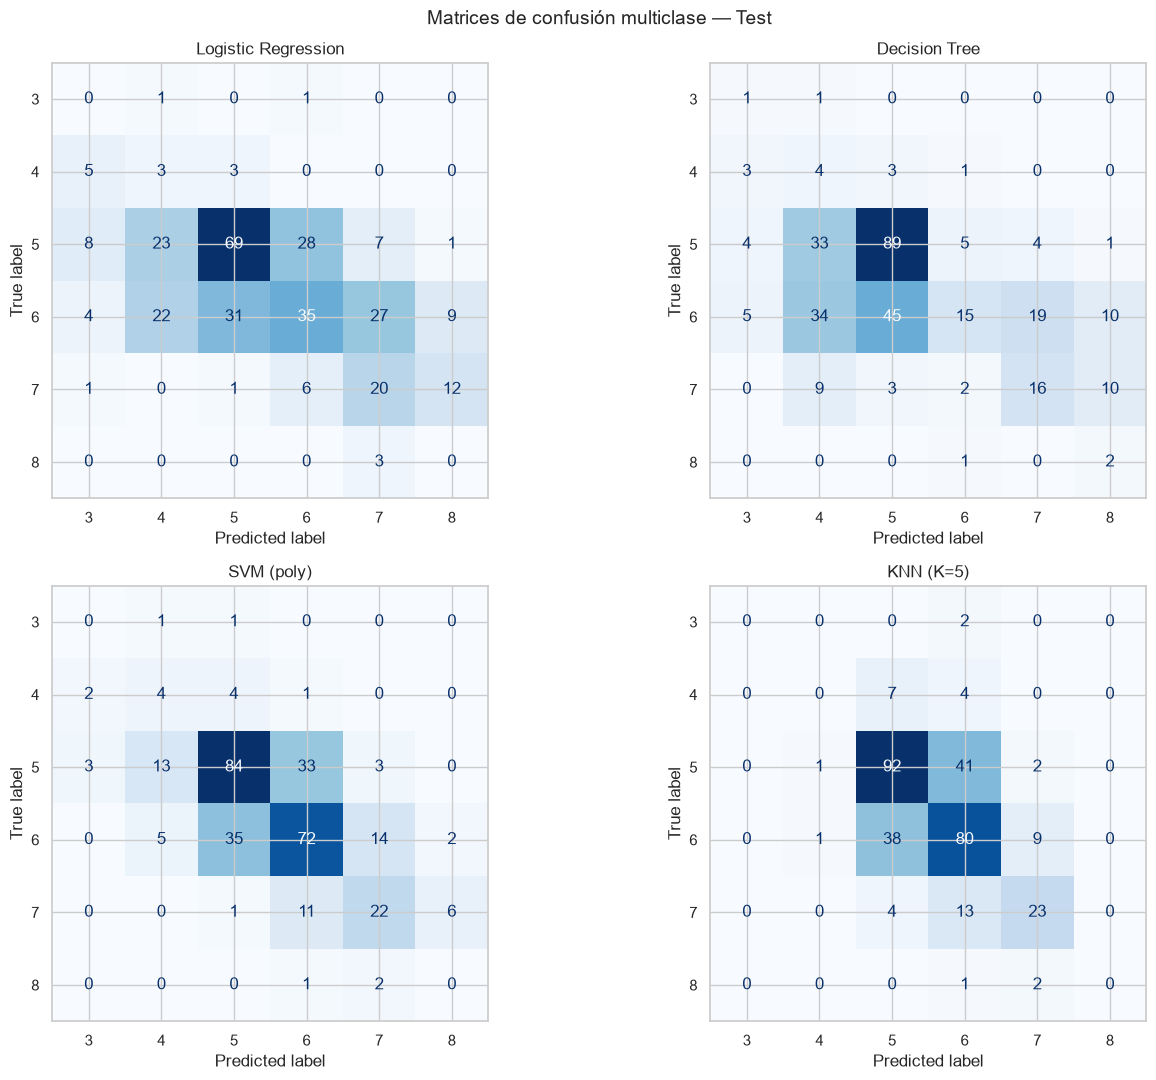

Logistic Regression  errores: 193 | a ±1 clase: 139 (72%)
Decision Tree        errores: 193 | a ±1 clase: 121 (63%)
SVM (poly)           errores: 138 | a ±1 clase: 121 (88%)
KNN (K=5)            errores: 125 | a ±1 clase: 111 (89%)


In [ ]:
# matrices de confusión

clases = sorted(y_mc.unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, (nombre, yp) in zip(axes.flatten(), pred_mc.items()):
    ConfusionMatrixDisplay.from_predictions(
        ymc_test, yp, labels=clases, cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(nombre)
plt.suptitle('Matrices de confusión multiclase — Test', fontsize=14)
plt.tight_layout()
plt.show()

# ¿Qué proporción de los errores cae en la clase vecina (±1)?
for nombre, yp in pred_mc.items():
    cm = confusion_matrix(ymc_test, yp, labels=clases)
    errores = cm.sum() - np.trace(cm)
    vecinos = sum(cm[i, j] for i in range(len(clases))
                  for j in range(len(clases)) if abs(i - j) == 1)
    print(f'{nombre:20s} errores: {errores:3d} | a ±1 clase: {vecinos:3d} ({vecinos/errores:.0%})')

In [ ]:
# F1 por clase

tabla_f1 = pd.DataFrame(
    {n: f1_score(ymc_test, yp, labels=clases, average=None, zero_division=0)
     for n, yp in pred_mc.items()},
    index=clases).round(3)
tabla_f1.index.name = 'quality'
tabla_f1['Soporte test'] = ymc_test.value_counts().sort_index()
display(tabla_f1)

nombre_svm = f'SVM ({best_kernel})'
print(f'\nReporte por clase — {nombre_svm}')
print(classification_report(ymc_test, pred_mc[nombre_svm], zero_division=0))

,Logistic Regression,Decision Tree,SVM (poly),KNN (K=5),Soporte test
quality,,,,,
3,0.000,0.133,0.000,0.000,2
4,0.100,0.087,0.235,0.000,11
5,0.575,0.645,0.644,0.664,136
6,0.354,0.197,0.585,0.595,128
7,0.412,0.405,0.543,0.605,40
8,0.000,0.154,0.000,0.000,3



Reporte por clase — SVM (poly)
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.17      0.36      0.24        11
           5       0.67      0.62      0.64       136
           6       0.61      0.56      0.59       128
           7       0.54      0.55      0.54        40
           8       0.00      0.00      0.00         3

    accuracy                           0.57       320
   macro avg       0.33      0.35      0.33       320
weighted avg       0.60      0.57      0.58       320



In [ ]:
# comprobar el efecto de los duplicados

from sklearn.base import clone

df_u = df.drop_duplicates().reset_index(drop=True)
print(f'Filas: {len(df)} -> {len(df_u)} (duplicados eliminados: {len(df) - len(df_u)})')

Xu, yu = df_u[features], df_u['quality']
Xu_tr, Xu_te, yu_tr, yu_te = train_test_split(
    Xu, yu, test_size=0.20, random_state=RANDOM_STATE, stratify=yu)

filas = []
for nombre, modelo in modelos_mc.items():
    m = clone(modelo)   # copia sin entrenar, mismos hiperparámetros
    r = cross_validate(m, Xu_tr, yu_tr, cv=cv, scoring=['accuracy', 'f1_macro'])
    m.fit(Xu_tr, yu_tr)
    yp = m.predict(Xu_te)
    filas.append({'Modelo': nombre,
                  'Acc CV': r['test_accuracy'].mean(),
                  'F1 macro CV': r['test_f1_macro'].mean(),
                  'Acc Test': accuracy_score(yu_te, yp),
                  'F1 macro Test': f1_score(yu_te, yp, average='macro')})

pd.DataFrame(filas).set_index('Modelo').round(4)

Filas: 1599 -> 1359 (duplicados eliminados: 240)


,Acc CV,F1 macro CV,Acc Test,F1 macro Test
Modelo,,,,
Logistic Regression,0.4232,0.3134,0.4191,0.2488
Decision Tree,0.3120,0.2195,0.3162,0.2402
SVM (poly),0.5410,0.3377,0.5221,0.3019
KNN (K=5),0.5207,0.2575,0.5625,0.2733


### Conclusiones — Ejercicio 2

**Rendimiento respecto al caso binario.** Al pasar de 2 a 6 clases el rendimiento cae en todos los modelos: la accuracy en test va de 0.40 a 0.61 y el F1 macro de 0.24 a 0.33. La distribución es muy desbalanceada (clases 3 y 8 con 10 y 18 muestras en todo el dataset; 2 y 3 en test), por lo que las métricas de esas clases son ruido estadístico.

| Modelo | Accuracy (=F1 micro) | F1 macro | F1 weighted |
|---|---|---|---|
| Logistic Regression | 0.3969 | 0.2402 | 0.4408 |
| Decision Tree | 0.3969 | 0.2702 | 0.4089 |
| SVM (poly) | 0.5688 | 0.3346 | 0.5837 |
| KNN (K=5) | 0.6094 | 0.3107 | 0.5959 |

**Clases más difíciles.**
1. Las clases extremas (3, 4 y 8) casi no se detectan: KNN obtiene F1 = 0 en las tres y solo el SVM identifica parcialmente la clase 4 (F1 = 0.235).
2. La mayor confusión entre clases con soporte suficiente ocurre entre 5 y 6, y entre 6 y 7. Entre las clases grandes, la 6 es la más difícil de aislar.
3. Entre el 63 % y el 89 % de los errores caen en la clase vecina (±1), lo que refleja la naturaleza ordinal de `quality` y la subjetividad de las puntuaciones.

**Efecto de los modelos.** LR y árbol (con `class_weight='balanced'`) sacrifican accuracy al predecir clases raras. KNN alcanza la mejor accuracy porque predice casi solo las clases 5, 6 y 7. El SVM obtiene el mejor F1 macro tanto en CV (0.3369) como en test (0.3346).

**Efecto de los duplicados.** El dataset contiene 240 filas duplicadas (15 %). Al eliminarlas, la accuracy CV de KNN cae 5.5 pp (0.5762 → 0.5207), frente a 1.6–2.2 pp en los demás modelos, lo que sugiere que su ventaja aparente en accuracy se debía en parte a vecinos duplicados. El SVM se mantiene primero en F1 macro CV (0.3377).

**Elección de la métrica.**
- *Micro*: coincide exactamente con la accuracy en clasificación multiclase de etiqueta única; no aporta información adicional y queda dominada por las clases 5 y 6.
- *Weighted*: pondera por soporte; es un buen resumen global pero oculta el fracaso en las clases minoritarias.
- *Macro*: trata todas las clases por igual y expone las debilidades en 3, 4 y 8. Se recomienda como métrica principal cuando todas las calidades importan, apoyada por el reporte por clase. Su limitación es la alta varianza cuando el soporte es de 2–3 muestras.

**Conclusión.** Tratar `quality` como problema multiclase nominal es una simplificación fuerte: el desbalance y el solapamiento entre clases vecinas limitan a todos los modelos. Alternativas más adecuadas: clasificación ordinal, regresión con redondeo, agrupar las clases extremas (p. ej. ≤4 y ≥7) o métricas tolerantes al error de ±1 clase.

### Resolución — Ejercicio 3: Dataset propio
**Dataset:** Predict Students' Dropout and Academic Success (UCI) — 4424 estudiantes, 36 variables.

**Problema:** clasificación multiclase. Predecir si un estudiante *abandona* (Dropout), *sigue matriculado* (Enrolled) o *se gradúa* (Graduate).

**Plan:**
1. Carga y exploración de datos
2. Preprocesamiento (variables numéricas, categóricas y binarias)
3. Entrenamiento de los 4 modelos: Regresión Logística, Árbol de Decisión, SVM y KNN
4. Análisis comparativo (métricas, matrices de confusión, F1 por clase)
5. Conclusiones

In [ ]:
# carga de datos y preprocesamiento

import os
from sklearn.compose import ColumnTransformer      # aplica un preprocesamiento distinto a cada grupo de columnas
from sklearn.preprocessing import OneHotEncoder    # convierte categorías en columnas de 0 y 1

RUTA = 'Predict-Students-Dropout-and-Academic-Success.csv'

# Verificamos que el archivo esté en la misma carpeta del notebook
if not os.path.exists(RUTA):
    raise FileNotFoundError(f'No encuentro {RUTA} en {os.getcwd()}')

# sep=';'            -> el archivo separa columnas con punto y coma
# encoding='utf-8-sig' -> elimina el carácter invisible (BOM) del inicio
df_es = pd.read_csv(RUTA, sep=';', encoding='utf-8-sig')

# Quita espacios y tabs escondidos en los nombres de columnas
df_es.columns = df_es.columns.str.strip()

print(f'Dataset: {df_es.shape[0]} estudiantes, {df_es.shape[1] - 1} variables + Target')
print(f'Valores nulos: {df_es.isna().sum().sum()} | Filas duplicadas: {df_es.duplicated().sum()}')
df_es.head(3)

Dataset: 4424 estudiantes, 36 variables + Target
Valores nulos: 0 | Filas duplicadas: 0


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout


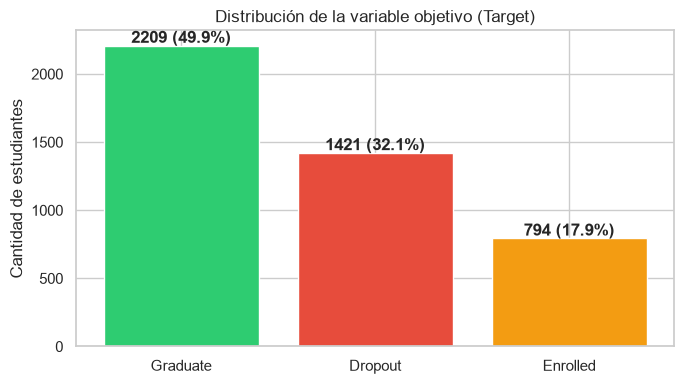

Clase mayoritaria / minoritaria: 2.8 : 1


In [42]:
# Distribución de la variable objetivo (Target)

# Cuántos estudiantes hay en cada clase, en cantidad y en porcentaje
conteo = df_es['Target'].value_counts()
porc = df_es['Target'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 4))
colores = {'Graduate': '#2ecc71', 'Enrolled': '#f39c12', 'Dropout': '#e74c3c'}
ax.bar(conteo.index, conteo.values, color=[colores[c] for c in conteo.index])

# Escribe la cantidad y el porcentaje encima de cada barra
for i, (c, p) in enumerate(zip(conteo.values, porc.values)):
    ax.text(i, c + 20, f'{c} ({p:.1f}%)', ha='center', fontweight='bold')

ax.set_title('Distribución de la variable objetivo (Target)')
ax.set_ylabel('Cantidad de estudiantes')
plt.tight_layout()
plt.show()

print(f'Clase mayoritaria / minoritaria: {conteo.max() / conteo.min():.1f} : 1')

In [43]:
# Ocho variables representativas (rendimiento académico, edad, situación económica)
clave = ['Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)',
         'Curricular units 2nd sem (grade)', 'Admission grade', 'Age at enrollment',
         'Tuition fees up to date', 'Scholarship holder', 'Debtor']

# Promedio de cada variable por clase (filas = variables, columnas = clases)
resumen = df_es.groupby('Target')[clave].mean().T.round(2)
resumen = resumen[['Dropout', 'Enrolled', 'Graduate']]   # orden lógico de las columnas
resumen

Target,Dropout,Enrolled,Graduate
Curricular units 1st sem (approved),2.55,4.32,6.23
Curricular units 2nd sem (approved),1.94,4.06,6.18
Curricular units 2nd sem (grade),5.90,11.12,12.70
Admission grade,124.96,125.53,128.79
Age at enrollment,26.07,22.37,21.78
Tuition fees up to date,0.68,0.95,0.99
Scholarship holder,0.09,0.16,0.38
Debtor,0.22,0.11,0.05


In [ ]:
# clasificar las variables por tipo

# Variables que son códigos de categorías (no cantidades)
col_categoricas = ['Marital status', 'Application mode', 'Course', 'Previous qualification',
                   'Nacionality', "Mother's qualification", "Father's qualification",
                   "Mother's occupation", "Father's occupation"]

features_es = [c for c in df_es.columns if c != 'Target']

# Binarias: las que solo toman 2 valores distintos
col_binarias = [c for c in features_es if df_es[c].nunique() == 2]

# Numéricas: todo lo que no sea categórica ni binaria
col_numericas = [c for c in features_es if c not in col_categoricas + col_binarias]

print(f'Categóricas (códigos):   {len(col_categoricas)}')
print(f'Binarias (0/1):          {len(col_binarias)}')
print(f'Numéricas:               {len(col_numericas)}')
print('\nCategorías distintas en cada variable categórica:')
print(df_es[col_categoricas].nunique().sort_values(ascending=False).to_string())

Categóricas (códigos):   9
Binarias (0/1):          8
Numéricas:               19

Categorías distintas en cada variable categórica:
Father's occupation       46
Father's qualification    34
Mother's occupation       32
Mother's qualification    29
Nacionality               21
Application mode          18
Previous qualification    17
Course                    17
Marital status             6


In [45]:
# separar train/test y construir el preprocesador

X_es = df_es[features_es]     # variables de entrada
y_es = df_es['Target']        # lo que queremos predecir

# stratify=y_es mantiene las mismas proporciones de clase en train y en test
X_es_train, X_es_test, y_es_train, y_es_test = train_test_split(
    X_es, y_es, test_size=0.20, random_state=RANDOM_STATE, stratify=y_es)

print(f'Train: {len(X_es_train)} | Test: {len(X_es_test)}')
print('Proporción en train:', (y_es_train.value_counts(normalize=True) * 100).round(1).to_dict())
print('Proporción en test: ', (y_es_test.value_counts(normalize=True) * 100).round(1).to_dict())

# Cada grupo de columnas recibe su propio tratamiento
preprocesador = ColumnTransformer([
    ('num', StandardScaler(), col_numericas),                       # numéricas: media 0, desviación 1
    ('cat', OneHotEncoder(handle_unknown='ignore'), col_categoricas),  # categóricas: una columna 0/1 por categoría
    ('bin', 'passthrough', col_binarias)                            # binarias: sin cambios
])

# Validación cruzada estratificada de 5 folds (se usará en todos los modelos)
cv_es = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Solo para contar columnas resultantes
Xt = preprocesador.fit_transform(X_es_train)
print(f'Columnas antes: {X_es_train.shape[1]} -> después del preprocesamiento: {Xt.shape[1]}')



Train: 3539 | Test: 885
Proporción en train: {'Graduate': 49.9, 'Dropout': 32.1, 'Enrolled': 17.9}
Proporción en test:  {'Graduate': 49.9, 'Dropout': 32.1, 'Enrolled': 18.0}
Columnas antes: 36 -> después del preprocesamiento: 236


In [46]:
# función de evaluación y línea base

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate

resultados_cv_es = {}   # aquí se guardan los resultados de cada modelo

def evaluar_cv(nombre, modelo):
    """Evalúa un modelo con CV de 5 folds y guarda accuracy y F1 macro (validación y train)."""
    r = cross_validate(modelo, X_es_train, y_es_train, cv=cv_es,
                       scoring=['accuracy', 'f1_macro'], return_train_score=True)
    resultados_cv_es[nombre] = {
        'Accuracy CV':    r['test_accuracy'].mean(),
        'F1 macro CV':    r['test_f1_macro'].mean(),
        'F1 macro std':   r['test_f1_macro'].std(),
        'F1 macro Train': r['train_f1_macro'].mean()
    }
    print(f'{nombre:22s} Acc CV = {r["test_accuracy"].mean():.4f} | '
          f'F1 macro CV = {r["test_f1_macro"].mean():.4f} ± {r["test_f1_macro"].std():.4f} | '
          f'F1 macro Train = {r["train_f1_macro"].mean():.4f}')
    return r

# Línea base: siempre predice la clase más frecuente (Graduate)
base = DummyClassifier(strategy='most_frequent')
_ = evaluar_cv('Baseline (siempre Graduate)', base)

Baseline (siempre Graduate) Acc CV = 0.4993 | F1 macro CV = 0.2220 ± 0.0002 | F1 macro Train = 0.2220


In [47]:
# Regresión logística con preprocesamiento (escalado y one-hot encoding)

pipe_lr_es = Pipeline([
    ('prep', preprocesador),                      # paso 1: preparar los datos
    ('clf', LogisticRegression(max_iter=2000,     # paso 2: el modelo
                               class_weight='balanced',
                               random_state=RANDOM_STATE))
])

_ = evaluar_cv('Logistic Regression', pipe_lr_es)

Logistic Regression    Acc CV = 0.7513 | F1 macro CV = 0.7095 ± 0.0145 | F1 macro Train = 0.7671


Mejor profundidad: 5 (F1 macro CV = 0.6707)


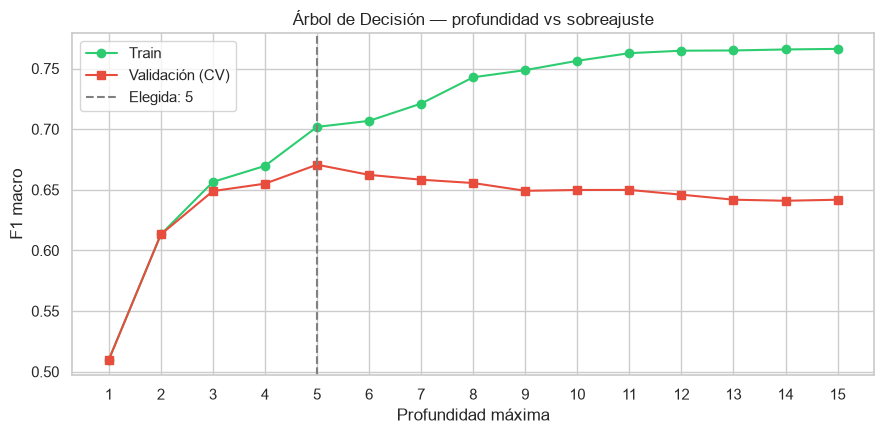

Decision Tree (prof=5) Acc CV = 0.7056 | F1 macro CV = 0.6707 ± 0.0121 | F1 macro Train = 0.7019


In [48]:
# Árbol de decisión con preprocesamiento (no requiere escalado)

profundidades = range(1, 16)
f1_train_dt, f1_val_dt = [], []

for d in profundidades:
    dt = Pipeline([
        ('prep', preprocesador),
        ('clf', DecisionTreeClassifier(max_depth=d,
                                       min_samples_leaf=10,      # cada hoja debe tener al menos 10 estudiantes
                                       class_weight='balanced',
                                       random_state=RANDOM_STATE))
    ])
    r = cross_validate(dt, X_es_train, y_es_train, cv=cv_es,
                       scoring='f1_macro', return_train_score=True)
    f1_train_dt.append(r['train_score'].mean())
    f1_val_dt.append(r['test_score'].mean())

# Profundidad con el mejor F1 en validación
mejor_prof = list(profundidades)[int(np.argmax(f1_val_dt))]
print(f'Mejor profundidad: {mejor_prof} (F1 macro CV = {max(f1_val_dt):.4f})')

# Gráfico: train vs validación según la profundidad
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(profundidades, f1_train_dt, 'o-', label='Train', color='#2ecc71')
ax.plot(profundidades, f1_val_dt, 's-', label='Validación (CV)', color='#e74c3c')
ax.axvline(mejor_prof, color='gray', linestyle='--', label=f'Elegida: {mejor_prof}')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1 macro')
ax.set_title('Árbol de Decisión — profundidad vs sobreajuste')
ax.legend()
ax.set_xticks(list(profundidades))
plt.tight_layout()
plt.show()

# Árbol final con la profundidad elegida
pipe_dt_es = Pipeline([
    ('prep', preprocesador),
    ('clf', DecisionTreeClassifier(max_depth=mejor_prof, min_samples_leaf=10,
                                   class_weight='balanced', random_state=RANDOM_STATE))
])
_ = evaluar_cv(f'Decision Tree (prof={mejor_prof})', pipe_dt_es)

In [49]:
# Comparación de kernels para SVM (con preprocesamiento)

resultados_kernel = {}

for kernel in ['linear', 'rbf', 'poly']:
    svm = Pipeline([
        ('prep', preprocesador),
        ('clf', SVC(kernel=kernel, class_weight='balanced', random_state=RANDOM_STATE))
    ])
    s = cross_validate(svm, X_es_train, y_es_train, cv=cv_es, scoring='f1_macro')['test_score']
    resultados_kernel[kernel] = s.mean()
    print(f'SVM ({kernel:6s}) — F1 macro CV: {s.mean():.4f} ± {s.std():.4f}')

mejor_kernel_es = max(resultados_kernel, key=resultados_kernel.get)
print(f'\nMejor kernel: {mejor_kernel_es}')

# SVM final con el mejor kernel
pipe_svm_es = Pipeline([
    ('prep', preprocesador),
    ('clf', SVC(kernel=mejor_kernel_es, class_weight='balanced', random_state=RANDOM_STATE))
])
_ = evaluar_cv(f'SVM ({mejor_kernel_es})', pipe_svm_es)

SVM (linear) — F1 macro CV: 0.7119 ± 0.0136
SVM (rbf   ) — F1 macro CV: 0.7134 ± 0.0168
SVM (poly  ) — F1 macro CV: 0.6836 ± 0.0128

Mejor kernel: rbf
SVM (rbf)              Acc CV = 0.7536 | F1 macro CV = 0.7134 ± 0.0168 | F1 macro Train = 0.8185


Mejor K: 13 (F1 macro CV = 0.6132)


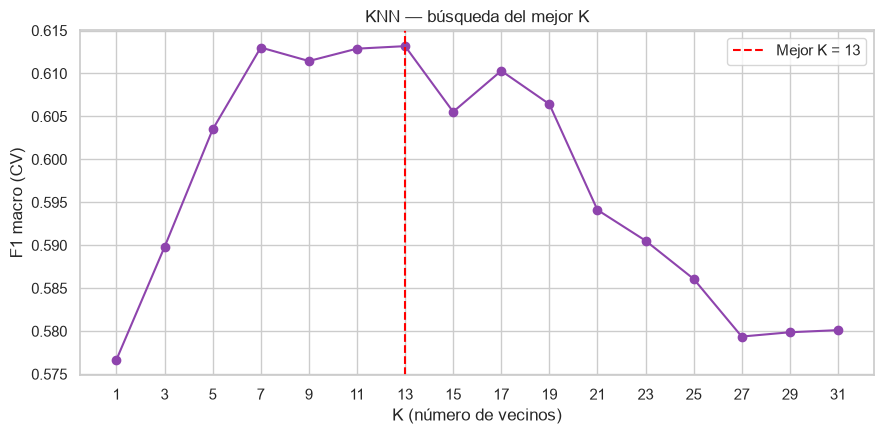

KNN (K=13)             Acc CV = 0.7174 | F1 macro CV = 0.6132 ± 0.0243 | F1 macro Train = 0.6582


In [50]:
# Búsqueda del K óptimo para KNN (con preprocesamiento)

valores_k = list(range(1, 32, 2))     # 1, 3, 5, ..., 31
f1_knn = []

for k in valores_k:
    knn = Pipeline([
        ('prep', preprocesador),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    s = cross_validate(knn, X_es_train, y_es_train, cv=cv_es, scoring='f1_macro')['test_score']
    f1_knn.append(s.mean())

mejor_k_es = valores_k[int(np.argmax(f1_knn))]
print(f'Mejor K: {mejor_k_es} (F1 macro CV = {max(f1_knn):.4f})')

# Gráfico: F1 macro según K
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(valores_k, f1_knn, 'o-', color='#8e44ad')
ax.axvline(mejor_k_es, color='red', linestyle='--', label=f'Mejor K = {mejor_k_es}')
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('F1 macro (CV)')
ax.set_title('KNN — búsqueda del mejor K')
ax.legend()
ax.set_xticks(valores_k)
plt.tight_layout()
plt.show()

# KNN final
pipe_knn_es = Pipeline([
    ('prep', preprocesador),
    ('clf', KNeighborsClassifier(n_neighbors=mejor_k_es))
])
_ = evaluar_cv(f'KNN (K={mejor_k_es})', pipe_knn_es)

In [51]:
# Resumen de resultados de validación cruzada

tabla_cv_es = pd.DataFrame(resultados_cv_es).T.round(4)
tabla_cv_es['Brecha (Train - CV)'] = (tabla_cv_es['F1 macro Train'] - tabla_cv_es['F1 macro CV']).round(4)
tabla_cv_es.sort_values('F1 macro CV', ascending=False)

,Accuracy CV,F1 macro CV,F1 macro std,F1 macro Train,Brecha (Train - CV)
SVM (rbf),0.7536,0.7134,0.0168,0.8185,0.1051
Logistic Regression,0.7513,0.7095,0.0145,0.7671,0.0576
Decision Tree (prof=5),0.7056,0.6707,0.0121,0.7019,0.0312
KNN (K=13),0.7174,0.6132,0.0243,0.6582,0.0450
Baseline (siempre Graduate),0.4993,0.2220,0.0002,0.2220,0.0000


In [52]:
# evaluación final en el conjunto de test

from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score)

# Los 4 pipelines definidos en la Ronda 2
modelos_es = {
    'Logistic Regression':               pipe_lr_es,
    f'Decision Tree (prof={mejor_prof})': pipe_dt_es,
    f'SVM ({mejor_kernel_es})':           pipe_svm_es,
    f'KNN (K={mejor_k_es})':              pipe_knn_es,
}
clases_es = ['Dropout', 'Enrolled', 'Graduate']   # orden fijo para tablas y gráficos

pred_es = {}      # aquí se guardan las predicciones de cada modelo
filas = []
for nombre, modelo in modelos_es.items():
    modelo.fit(X_es_train, y_es_train)            # entrena con TODO el train
    y_pred = modelo.predict(X_es_test)            # predice el test (datos nuevos)
    pred_es[nombre] = y_pred
    filas.append({
        'Modelo': nombre,
        'Accuracy':        accuracy_score(y_es_test, y_pred),
        'F1 macro':        f1_score(y_es_test, y_pred, average='macro'),
        'F1 weighted':     f1_score(y_es_test, y_pred, average='weighted'),
        'Precision macro': precision_score(y_es_test, y_pred, average='macro'),
        'Recall macro':    recall_score(y_es_test, y_pred, average='macro')
    })

test_es = pd.DataFrame(filas).set_index('Modelo').round(4)
test_es

,Accuracy,F1 macro,F1 weighted,Precision macro,Recall macro
Modelo,,,,,
Logistic Regression,0.7254,0.6885,0.7384,0.6969,0.7007
Decision Tree (prof=5),0.6723,0.6468,0.6942,0.6725,0.6657
SVM (rbf),0.7277,0.6874,0.7382,0.6950,0.6955
KNN (K=13),0.7028,0.5947,0.6742,0.6495,0.5886


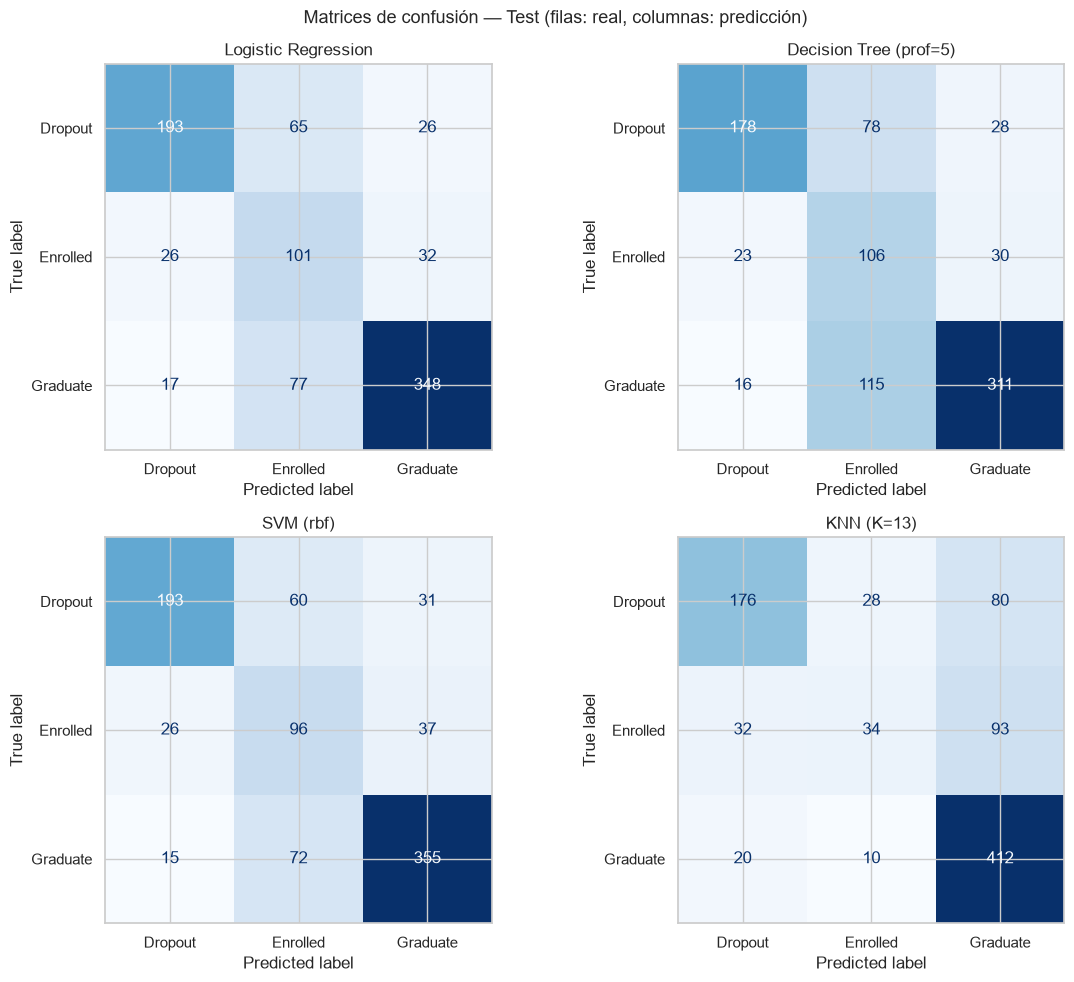

Recall por clase (% de cada clase real que el modelo detecta):
  Logistic Regression      Dropout: 68.0% | Enrolled: 63.5% | Graduate: 78.7%
  Decision Tree (prof=5)   Dropout: 62.7% | Enrolled: 66.7% | Graduate: 70.4%
  SVM (rbf)                Dropout: 68.0% | Enrolled: 60.4% | Graduate: 80.3%
  KNN (K=13)               Dropout: 62.0% | Enrolled: 21.4% | Graduate: 93.2%


In [53]:
# Matrices de confusión comparativas

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (nombre, y_pred) in zip(axes.flatten(), pred_es.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_es_test, y_pred, labels=clases_es, cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(nombre)
plt.suptitle('Matrices de confusión — Test (filas: real, columnas: predicción)', fontsize=13)
plt.tight_layout()
plt.show()

# Porcentaje de estudiantes de cada clase que el modelo identificó correctamente
print('Recall por clase (% de cada clase real que el modelo detecta):')
for nombre, y_pred in pred_es.items():
    cm = confusion_matrix(y_es_test, y_pred, labels=clases_es)
    detalle = ' | '.join(f'{c}: {cm[i, i] / cm[i].sum():.1%}' for i, c in enumerate(clases_es))
    print(f'  {nombre:24s} {detalle}')

In [54]:
# Comparación de métricas por clase

# Tabla: F1 de cada clase (filas) para cada modelo (columnas)
f1_clase = pd.DataFrame(
    {n: f1_score(y_es_test, yp, labels=clases_es, average=None) for n, yp in pred_es.items()},
    index=clases_es).round(3)
f1_clase['Soporte test'] = y_es_test.value_counts()[clases_es].values   # cantidad real de cada clase
display(f1_clase)

# Reporte completo del mejor modelo (según F1 macro en test)
nombre_mejor = test_es['F1 macro'].idxmax()
print(f'\nMejor modelo en test: {nombre_mejor}')
print(classification_report(y_es_test, pred_es[nombre_mejor]))

,Logistic Regression,Decision Tree (prof=5),SVM (rbf),KNN (K=13),Soporte test
Dropout,0.742,0.711,0.745,0.688,284
Enrolled,0.502,0.463,0.496,0.294,159
Graduate,0.821,0.767,0.821,0.802,442



Mejor modelo en test: Logistic Regression
              precision    recall  f1-score   support

     Dropout       0.82      0.68      0.74       284
    Enrolled       0.42      0.64      0.50       159
    Graduate       0.86      0.79      0.82       442

    accuracy                           0.73       885
   macro avg       0.70      0.70      0.69       885
weighted avg       0.77      0.73      0.74       885



,F1 macro CV,F1 macro Test,Diferencia (Test - CV)
Logistic Regression,0.7095,0.6885,-0.0210
Decision Tree (prof=5),0.6707,0.6468,-0.0239
SVM (rbf),0.7134,0.6874,-0.0260
KNN (K=13),0.6132,0.5947,-0.0185


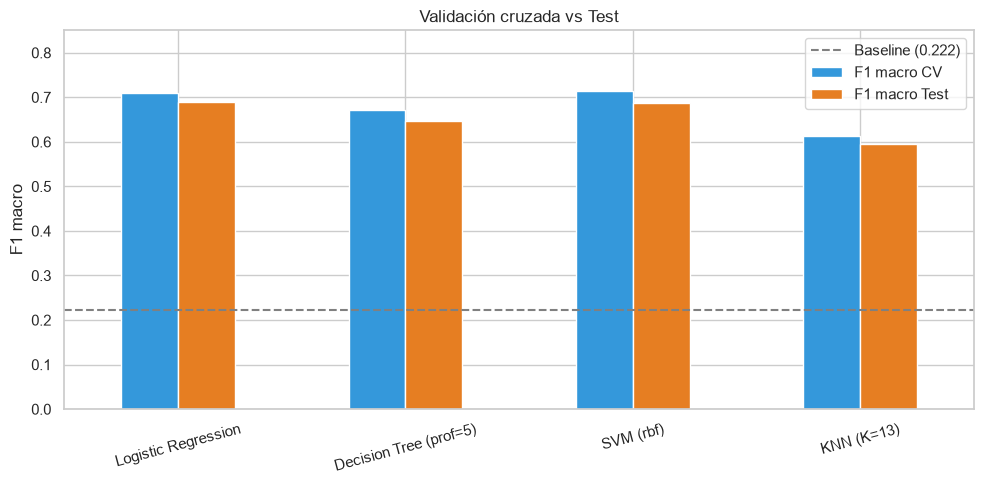

In [55]:
# Comparación de resultados CV vs Test

comp = pd.DataFrame({
    'F1 macro CV':   {n: resultados_cv_es[n]['F1 macro CV'] for n in modelos_es},
    'F1 macro Test': test_es['F1 macro']
})
comp['Diferencia (Test - CV)'] = comp['F1 macro Test'] - comp['F1 macro CV']
display(comp.round(4))

# Gráfico de barras: CV vs Test, con la línea base como referencia
ax = comp[['F1 macro CV', 'F1 macro Test']].plot(
    kind='bar', figsize=(10, 5), color=['#3498db', '#e67e22'], rot=15)
ax.axhline(resultados_cv_es['Baseline (siempre Graduate)']['F1 macro CV'],
           color='gray', linestyle='--', label='Baseline (0.222)')
ax.set_ylabel('F1 macro')
ax.set_title('Validación cruzada vs Test')
ax.set_ylim(0, 0.85)
ax.legend()
plt.tight_layout()
plt.show()

In [56]:
# Bootstrap para intervalos de confianza del F1 macro en test

rng = np.random.default_rng(RANDOM_STATE)
y_true = y_es_test.to_numpy()

# 1000 remuestreos del test (mismos estudiantes elegidos para todos los modelos)
idx_boot = [rng.integers(0, len(y_true), len(y_true)) for _ in range(1000)]

for nombre, y_pred in pred_es.items():
    yp = np.asarray(y_pred)
    vals = [f1_score(y_true[i], yp[i], average='macro') for i in idx_boot]
    lo, hi = np.percentile(vals, [2.5, 97.5])         # rango que contiene el 95 % central
    print(f'{nombre:24s} F1 macro test = {f1_score(y_true, yp, average="macro"):.4f}  '
          f'IC95% = [{lo:.4f}, {hi:.4f}]')

# Diferencia directa entre SVM y Regresión Logística
n_svm = f'SVM ({mejor_kernel_es})'
diff = [f1_score(y_true[i], np.asarray(pred_es[n_svm])[i], average='macro')
        - f1_score(y_true[i], np.asarray(pred_es['Logistic Regression'])[i], average='macro')
        for i in idx_boot]
print(f'\nSVM - LR: media = {np.mean(diff):.4f}, IC95% = {np.percentile(diff, [2.5, 97.5]).round(4)}')

Logistic Regression      F1 macro test = 0.6885  IC95% = [0.6561, 0.7201]
Decision Tree (prof=5)   F1 macro test = 0.6468  IC95% = [0.6158, 0.6768]
SVM (rbf)                F1 macro test = 0.6874  IC95% = [0.6559, 0.7195]
KNN (K=13)               F1 macro test = 0.5947  IC95% = [0.5593, 0.6266]

SVM - LR: media = -0.0014, IC95% = [-0.0253  0.0215]


### Conclusiones — Ejercicio 3: Student Dropout and Academic Success

**Problema y datos.** Clasificación multiclase de 4424 estudiantes en tres categorías: Graduate (49.9 %), Dropout (32.1 %) y Enrolled (17.9 %). El dataset no tiene nulos ni duplicados. Las 9 variables categóricas (curso, ocupación de los padres, etc.) se codificaron con one-hot y las 19 numéricas se estandarizaron, lo que llevó las columnas de 36 a 236. Todo el preprocesamiento se hizo dentro de pipelines para evitar fuga de información. Como métrica principal se usó el **F1 macro**, por el desbalance entre clases y porque castiga el mal desempeño en las clases minoritarias. La línea base (predecir siempre Graduate) obtiene accuracy 0.499 y F1 macro 0.222.

**Resultados.**

| Modelo | F1 macro CV | F1 macro Test | Accuracy Test | Brecha train–CV | F1 Enrolled (test) |
|---|---|---|---|---|---|
| Logistic Regression | 0.7095 | 0.6885 | 0.7254 | 0.058 | 0.502 |
| SVM (rbf) | 0.7134 | 0.6874 | 0.7277 | 0.105 | 0.496 |
| Decision Tree (prof=5) | 0.6707 | 0.6468 | 0.6723 | 0.031 | 0.463 |
| KNN (K=13) | 0.6132 | 0.5947 | 0.7028 | 0.045 | 0.294 |

**Hallazgos.**
1. **Regresión Logística y SVM están empatados.** La diferencia en F1 macro de test es de −0.0014 (IC 95 %: −0.025 a 0.022, que incluye el cero). El SVM con kernel lineal también rindió igual que el rbf (0.7119 vs 0.7134), lo que indica que las clases son separables de forma casi lineal.
2. **KNN es claramente el peor.** Su intervalo de confianza no se solapa con el de los dos mejores. La accuracy (0.703) es engañosa: acierta solo el 21.4 % de los estudiantes Enrolled y clasifica como Graduate a 80 de los 284 desertores (28 %), frente a 26 (9 %) de la regresión logística. Una causa probable es la alta dimensionalidad (236 columnas), donde las distancias pierden significado. KNN además no admite `class_weight`, por lo que no compite en igualdad de condiciones con los otros tres.
3. **`Enrolled` es la clase más difícil** para todos los modelos (F1 entre 0.29 y 0.50), lo que era previsible: son estudiantes en una situación intermedia, cuyos promedios caen entre los de Dropout y Graduate. La regresión logística logra recall 0.64 pero precisión 0.42: detecta a la mayoría a costa de muchas falsas alarmas, efecto del balanceo de clases.
4. **Perfil de quienes abandonan:** aprueban menos materias en el primer semestre (2.55 vs 6.23 de los graduados), ingresan con más edad (26.1 vs 21.8 años), tienen más deudas (22 % vs 5 %) y menos becas (9 % vs 38 %). La nota de admisión casi no diferencia a las clases (125.0 vs 128.8).
5. **No hay sobreajuste especial en ningún modelo.** Todos bajan entre 1.9 y 2.6 puntos de F1 macro entre validación cruzada y test, de forma pareja. Esa caída es esperable porque los hiperparámetros se eligieron con la misma validación cruzada.

**Modelo recomendado: Regresión Logística.** Rinde igual que el SVM, sobreajusta menos (brecha 0.058 vs 0.105), es más rápido y sus coeficientes son interpretables, algo valioso si los resultados se presentan a la institución.

**Limitaciones.**
- Las variables del 2.º semestre solo existen a mitad de la carrera, por lo que el modelo sirve para detectar riesgo tardío, no al momento de matricularse. No se probó cuánto rendimiento se pierde sin ellas.
- Los intervalos por bootstrap solo capturan la variabilidad del conjunto de test, no la del entrenamiento.
- Con un F1 de ~0.50 en `Enrolled`, el modelo no es fiable para esa clase.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*